<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week12/Semana_12_%E2%80%93_Actividad_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

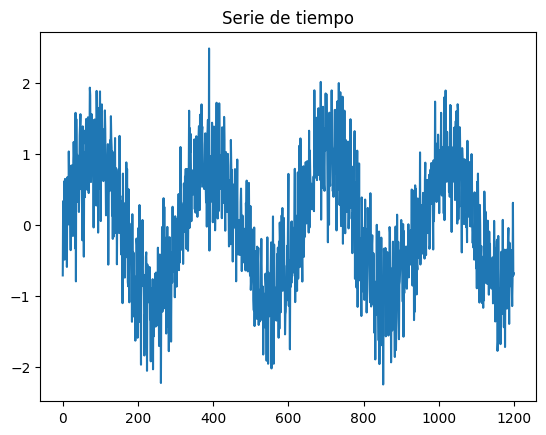

In [2]:
# Serie de tiempo sintética
def generate_time_series(n_steps=1000):
    t = np.arange(n_steps)
    series = np.sin(0.02 * t) + 0.5 * np.random.randn(n_steps)
    return series

series = generate_time_series(1200)

plt.plot(series)
plt.title("Serie de tiempo")
plt.show()

In [3]:
def create_dataset(series, window_size=20):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20
X, y = create_dataset(series, window_size)

# División entrenamiento / prueba
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Ajuste de dimensiones para redes neuronales
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [4]:
class SimpleAttention(layers.Layer):
    def __init__(self):
        super(SimpleAttention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer="random_normal",
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer="zeros",
                                 trainable=True)

    def call(self, inputs):
        # Cálculo de puntajes de atención
        score = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)

        # Aplicación de pesos a la secuencia
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

In [5]:
def build_model(window_size):
    inputs = layers.Input(shape=(window_size, 1))

    # Proyección inicial
    x = layers.Dense(32)(inputs)

    # Atención tipo Transformer
    attention_output = layers.MultiHeadAttention(
        num_heads=2, key_dim=16
    )(x, x)

    x = layers.Add()([x, attention_output])
    x = layers.LayerNormalization()(x)

    # Atención personalizada (interpretabilidad)
    context_vector, attention_weights = SimpleAttention()(x)

    outputs = layers.Dense(1)(context_vector)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_model(window_size)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 32)    │         64 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 32)    │      4,224 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 32)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_attention    │ [(None, 32),      │         52 │ layer_normalizat… │
│ (SimpleAttention)   │ (None, 20, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ simple_attention… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,437 (17.33 KB)

 Trainable params: 4,437 (17.33 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.3733 - mae: 0.4882 - val_loss: 0.2548 - val_mae: 0.4175
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3255 - mae: 0.4609 - val_loss: 0.2604 - val_mae: 0.4112
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3178 - mae: 0.4577 - val_loss: 0.2480 - val_mae: 0.4029
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3189 - mae: 0.4496 - val_loss: 0.2501 - val_mae: 0.3999
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3191 - mae: 0.4585 - val_loss: 0.2637 - val_mae: 0.4112
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3175 - mae: 0.4598 - val_loss: 0.2690 - val_mae: 0.4162
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3123 - mae: 0.4509 - val_loss: 0.2541 - val_mae: 0.4038
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3118 - mae: 0.4539 - val_loss: 0.2480 - val_mae: 0.4074
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.31

In [7]:
loss, mae = model.evaluate(X_test, y_test)
print("MAE en test:", mae)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2439 - mae: 0.3985 
MAE en test: 0.39852461218833923


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


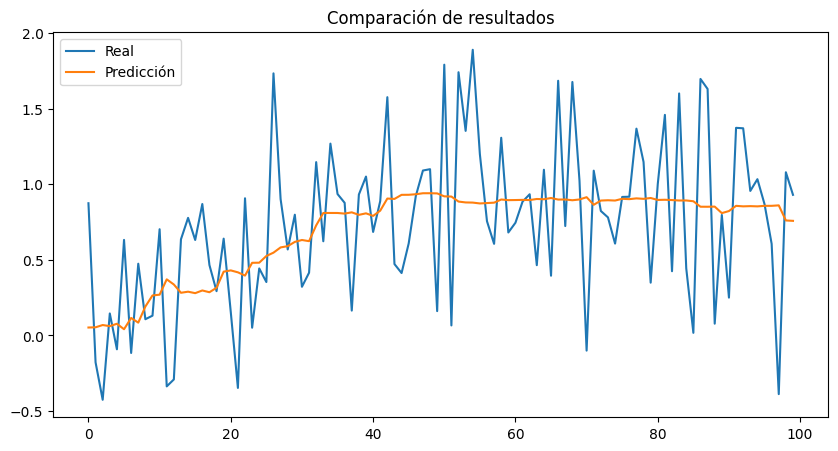

In [8]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test[:100], label="Real")
plt.plot(y_pred[:100], label="Predicción")
plt.legend()
plt.title("Comparación de resultados")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


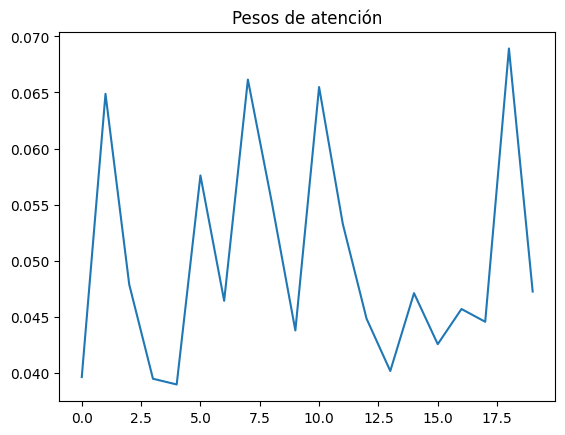

In [9]:
# Modelo auxiliar para extraer atención
attention_model = models.Model(
    inputs=model.input,
    outputs=model.layers[-2].output[1]  # pesos de atención
)

sample = X_test[0:1]
attention_weights = attention_model.predict(sample)

plt.plot(attention_weights.flatten())
plt.title("Pesos de atención")
plt.show()

# Readme

## Comparación:

- Las RNN procesan la secuencia de forma secuencial, lo que limita el paralelismo.
- Los mecanismos de atención permiten enfocarse en partes relevantes de la secuencia sin depender estrictamente del orden.
- Los Transformers capturan mejor dependencias de largo plazo.
- En este experimento, el modelo con atención logra identificar qué pasos temporales son más relevantes.

## Análisis de corto vs largo plazo

- Ventanas pequeñas → modelo enfocado en dependencias de corto plazo.
- Atención permite asignar mayor peso a ciertos pasos incluso dentro de ventanas largas.
- A diferencia de RNN, no hay degradación fuerte por distancia temporal.